In [18]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Load the dataset
df = pd.read_csv('Tweets.csv')


print("Original Data:")
print(df.head())


df = df[['text', 'airline_sentiment']]


#df = df[df['airline_sentiment'] != 'neutral']

print("\nData after selecting columns and removing neutral sentiment:")
print(df.head())

Original Data:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                

## Data Preprocessing (Improved)

We use **NLTK** for more advanced text processing:
1. **Tokenization**: `word_tokenize` handles punctuation and contractions better than simple `split()`.
2. **Lemmatization**: Converts words to their base form (e.g., "running" -> "run", "better" -> "good"), reducing vocabulary size and improving model generalization.
3. **Stopword Removal**: Removes common words that don't carry much sentiment.

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Download necessary NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Remove @mentions and URLs
    text = re.sub(r'@[A-Za-z0-9_]+|https?:\S+', '', text)
    
    # Remove anything that's not a letter (punctuations, numbers, etc.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenization using NLTK (better than split())
    tokens = word_tokenize(text)
    
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return tokens

# clean column
print("Preprocessing text... this may take a moment")
df['clean_text'] = df['text'].apply(preprocess_text)

print("Data after cleaning and preprocessing:")
df.head(30)

Preprocessing text... this may take a moment


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alexb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\alexb\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Data after cleaning and preprocessing:


,text,airline_sentiment,clean_text
0,@VirginAmerica What @dhepburn said.,neutral,[said]
1,@VirginAmerica plus you've added commercials t...,positive,"[plus, youve, added, commercial, experience, t..."
2,@VirginAmerica I didn't today... Must mean I n...,neutral,"[didnt, today, must, mean, need, take, another..."
3,@VirginAmerica it's really aggressive to blast...,negative,"[really, aggressive, blast, obnoxious, enterta..."
4,@VirginAmerica and it's a really big bad thing...,negative,"[really, big, bad, thing]"
5,@VirginAmerica seriously would pay $30 a fligh...,negative,"[seriously, would, pay, flight, seat, didnt, p..."
6,"@VirginAmerica yes, nearly every time I fly VX...",positive,"[yes, nearly, every, time, fly, vx, ear, worm,..."
7,@VirginAmerica Really missed a prime opportuni...,neutral,"[really, missed, prime, opportunity, men, with..."
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive,"[well, didntbut]"
9,"@VirginAmerica it was amazing, and arrived an ...",positive,"[amazing, arrived, hour, early, youre, good]"


## Feature Engineering

We use **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert text into numerical features.
- `max_features=5000`: We limit to the top 5000 most important words to keep the model efficient.

In [20]:
df.values

array([['@VirginAmerica What @dhepburn said.', 'neutral', list(['said'])],
       ["@VirginAmerica plus you've added commercials to the experience... tacky.",
        'positive',
        list(['plus', 'youve', 'added', 'commercial', 'experience', 'tacky'])],
       ["@VirginAmerica I didn't today... Must mean I need to take another trip!",
        'neutral',
        list(['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip'])],
       ...,
       ['@AmericanAir Please bring American Airlines to #BlackBerry10',
        'neutral',
        list(['please', 'bring', 'american', 'airline', 'blackberry'])],
       ["@AmericanAir you have my money, you change my flight, and don't answer your phones! Any other suggestions so I can make my commitment??",
        'negative',
        list(['money', 'change', 'flight', 'dont', 'answer', 'phone', 'suggestion', 'make', 'commitment'])],
       ['@AmericanAir we have 8 ppl so we need 2 know how many seats are on the next flight. Plz put 

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Before using TfidfVectorizer, we need to join our lists of tokens back into single strings.
df['clean_text_joined'] = df['clean_text'].apply(lambda tokens: ' '.join(tokens))

# features (X) and target/label (y)
X = df['clean_text_joined']
y = df['airline_sentiment']

# training set and testing set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialize TfidfVectorizer
# max_features=5000 means we'll only consider the top 5000 most important words.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit vectorizer on TRAINING data and transform
# learns vocabulary and IDF gives scores from training text.
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# TRANSFORM the TESTING data using the already-fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)


print("Shape of the training data matrix:", X_train_tfidf.shape)
print("Shape of the testing data matrix:", X_test_tfidf.shape)

Shape of the training data matrix: (11712, 5000)
Shape of the testing data matrix: (2928, 5000)


## Baseline Model Training

We start with a simple **Logistic Regression** model to establish a baseline performance.

Model Accuracy: 79.88%

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.67      0.48      0.56       580
    positive       0.82      0.62      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928


Confusion Matrix:


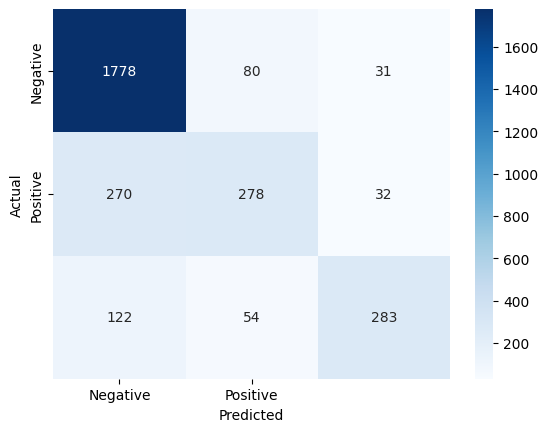

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# predictions on the unseen test data
y_pred = model.predict(X_test_tfidf)

# model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#  Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Advanced Training: Class Imbalance & Hyperparameter Tuning

1. **SMOTE (Synthetic Minority Over-sampling Technique)**: Our dataset is imbalanced (more negative tweets than positive). SMOTE creates synthetic examples of the minority class to balance the data.
2. **GridSearchCV**: We use Grid Search to find the best hyperparameters for both Logistic Regression and SVM (Support Vector Machine).
3. **SVM**: We test SVM as it often performs well on high-dimensional text data.

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use SMOTE to create a balanced training set
print("Balancing the training data with SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)
print("Data balanced.")

# grid of parameters to test for both models
# common settings to tune for these models
param_grid_lr = {'C': [0.1, 1, 10]}
param_grid_svc = {'C': [1, 10, 100], 'gamma': [0.1, 0.01]}

# GridSearchCV to find the best Logistic Regression model
print("\nTuning Logistic Regression model...")
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=3)
grid_lr.fit(X_train_smote, y_train_smote)
print(f"Best Logistic Regression parameters: {grid_lr.best_params_}")

# GridSearchCV to find the best SVC model
print("\nTuning Support Vector Machine (SVC) model...")
grid_svc = GridSearchCV(SVC(), param_grid_svc, cv=3)
grid_svc.fit(X_train_smote, y_train_smote)
print(f"Best SVC parameters: {grid_svc.best_params_}")

print("\n--- Improved Logistic Regression Results ---")
y_pred_lr = grid_lr.predict(X_test_tfidf)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\n--- Support Vector Machine (SVC) Results ---")
y_pred_svc = grid_svc.predict(X_test_tfidf)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred_svc) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

# visualize the confusion matrix of the better model
print("\nConfusion Matrix for the better model (SVC):")
cm = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Balancing the training data with SMOTE...
Data balanced.

Tuning Logistic Regression model...


c:\Users\alexb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Best Logistic Regression parameters: {'C': 10}

Tuning Support Vector Machine (SVC) model...


KeyboardInterrupt: 

## Save the Best Model

We save both the vectorizer and the best performing model (SVM) for use in the API.

In [6]:
import joblib


vectorizer_filename = 'tfidf_vectorizer.joblib'

# overwrite the old model file with new
model_filename = 'sentiment_model.joblib'

joblib.dump(tfidf_vectorizer, vectorizer_filename)

# Save new SVC model
# use 'grid_svc' because it is the trained GridSearchCV object
joblib.dump(grid_svc, model_filename)

print(f"Vectorizer saved to {vectorizer_filename}")
print(f"IMPROVED model saved to {model_filename}")

Vectorizer saved to tfidf_vectorizer.joblib
IMPROVED model saved to sentiment_model.joblib


In [7]:
df['clean_text_joined']

1             plus youve added commercial experience tacky
3        really aggressive blast obnoxious entertainmen...
4                                     really big bad thing
5        seriously would pay flight seat didnt playing ...
6        yes nearly every time fly vx ear worm wont go ...
                               ...                        
14633    flight cancelled flightled leaving tomorrow mo...
14634                                      right cue delay
14635                   thank got different flight chicago
14636    leaving minute late flight warning communicati...
14638    money change flight dont answer phone suggesti...
Name: clean_text_joined, Length: 11541, dtype: object

In [8]:
df['airline_sentiment']

1        positive
3        negative
4        negative
5        negative
6        positive
           ...   
14633    negative
14634    negative
14635    positive
14636    negative
14638    negative
Name: airline_sentiment, Length: 11541, dtype: object

In [9]:
tfidf_vectorizer

TfidfVectorizer(max_features=5000)

In [10]:
X_train

9498     another dead end handle aa lampf gave failed a...
10811    plane pbi clt knew frozen water also saw plane...
10831                        waiting bag min phl bag claim
10193    never heard back would help chance could bump ...
1212                                                thanks
                               ...                        
14349           get refund also apology deplorable service
6718                      need update flight amp hold hour
7098                                 lovely rt fleet fleek
1149     okay thanks could please update told airport s...
9639     ringling brother barnum bailey keep eye peeled...
Name: clean_text_joined, Length: 9232, dtype: object

In [11]:
y_train

9498     negative
10811    negative
10831    negative
10193    negative
1212     positive
           ...   
14349    negative
6718     negative
7098     positive
1149     negative
9639     negative
Name: airline_sentiment, Length: 9232, dtype: object

In [12]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 159)	0.20922159837746127
  (0, 888)	0.3427772529421375
  (0, 1137)	0.27725994460817055
  (0, 1722)	0.28796828058042895
  (0, 0)	0.21869967788821468
  (0, 2577)	0.39024534357494445
  (0, 1480)	0.2637887832133708
  (0, 1257)	0.30415777964307517
  (0, 122)	0.231584946050009
  (0, 4797)	0.39024534357494445
  (0, 1460)	0.2586996941241504
  (0, 2841)	0.20944037007576988


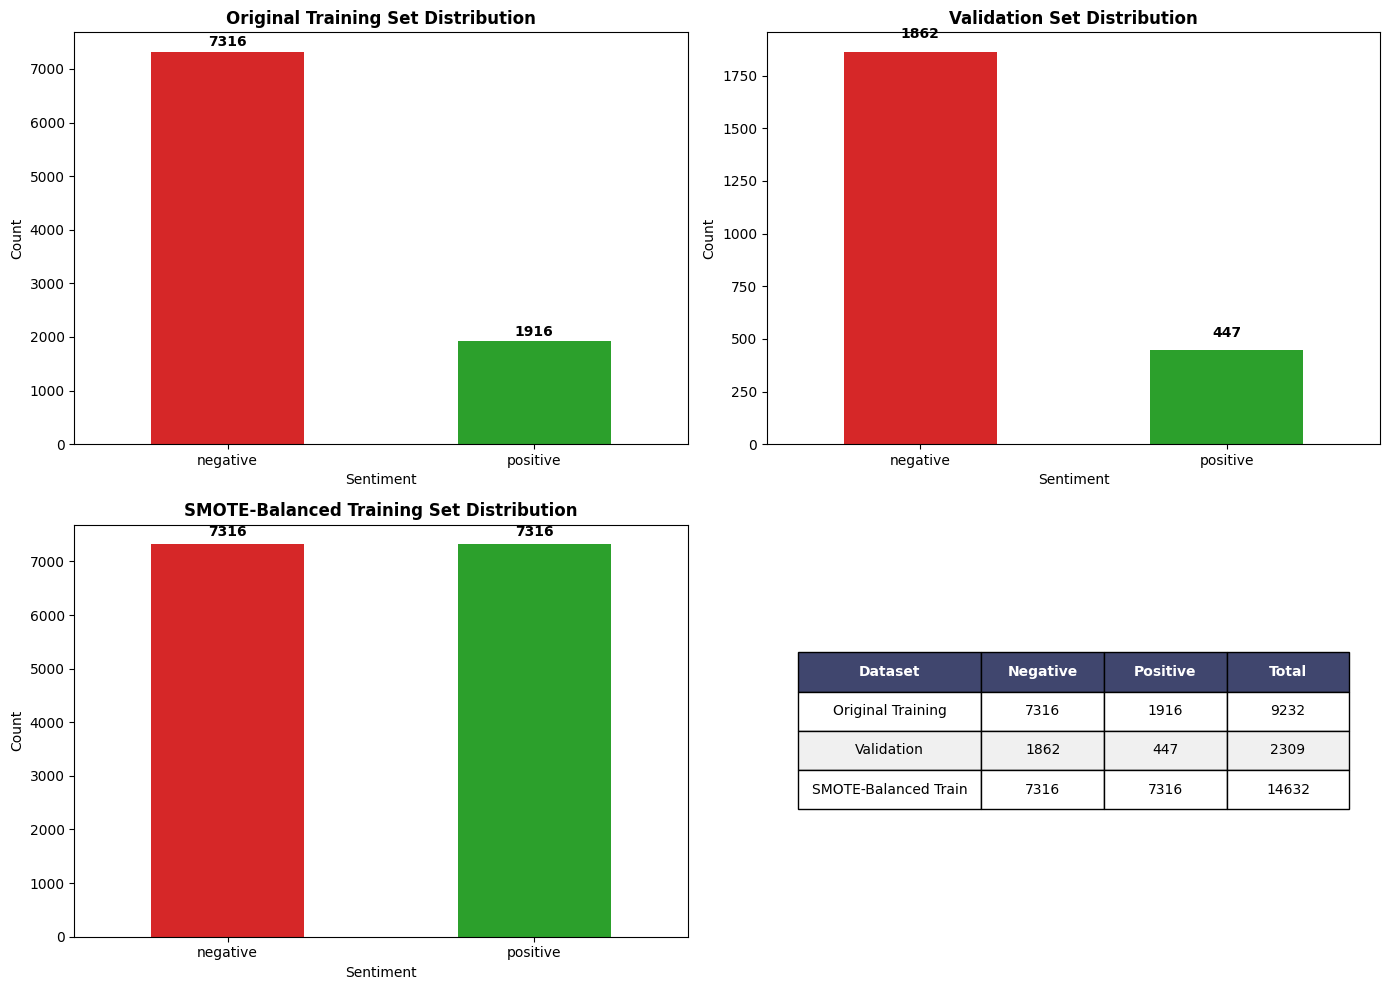

SENTIMENT DISTRIBUTION SUMMARY

Original Training Set:
airline_sentiment
negative    7316
positive    1916
Name: count, dtype: int64
Ratio (Negative:Positive): 3.82:1

Validation Set:
airline_sentiment
negative    1862
positive     447
Name: count, dtype: int64
Ratio (Negative:Positive): 4.17:1

SMOTE-Balanced Training Set:
airline_sentiment
negative    7316
positive    7316
Name: count, dtype: int64
Ratio (Negative:Positive): 1.00:1


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots to show sentiment distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Original Training Set Distribution
ax1 = axes[0, 0]
y_train.value_counts().plot(kind='bar', ax=ax1, color=['#d62728', '#2ca02c'])
ax1.set_title('Original Training Set Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(y_train.value_counts()):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Validation Set Distribution
ax2 = axes[0, 1]
y_test.value_counts().plot(kind='bar', ax=ax2, color=['#d62728', '#2ca02c'])
ax2.set_title('Validation Set Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)
for i, v in enumerate(y_test.value_counts()):
    ax2.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# 3. SMOTE-Balanced Training Set Distribution
ax3 = axes[1, 0]
import pandas as pd
y_train_smote_series = pd.Series(y_train_smote)
y_train_smote_series.value_counts().plot(kind='bar', ax=ax3, color=['#d62728', '#2ca02c'])
ax3.set_title('SMOTE-Balanced Training Set Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=0)
for i, v in enumerate(y_train_smote_series.value_counts()):
    ax3.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# 4. Comparison table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

comparison_data = [
    ['Dataset', 'Negative', 'Positive', 'Total'],
    ['Original Training', y_train.value_counts().get('negative', 0), y_train.value_counts().get('positive', 0), len(y_train)],
    ['Validation', y_test.value_counts().get('negative', 0), y_test.value_counts().get('positive', 0), len(y_test)],
    ['SMOTE-Balanced Train', y_train_smote_series.value_counts().get('negative', 0), y_train_smote_series.value_counts().get('positive', 0), len(y_train_smote)]
]

table = ax4.table(cellText=comparison_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, 4):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 60)
print("SENTIMENT DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"\nOriginal Training Set:")
print(y_train.value_counts())
print(f"Ratio (Negative:Positive): {y_train.value_counts().get('negative', 0) / y_train.value_counts().get('positive', 0):.2f}:1")

print(f"\nValidation Set:")
print(y_test.value_counts())
print(f"Ratio (Negative:Positive): {y_test.value_counts().get('negative', 0) / y_test.value_counts().get('positive', 0):.2f}:1")

print(f"\nSMOTE-Balanced Training Set:")
print(y_train_smote_series.value_counts())
print(f"Ratio (Negative:Positive): {y_train_smote_series.value_counts().get('negative', 0) / y_train_smote_series.value_counts().get('positive', 0):.2f}:1")
print("=" * 60)